<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/emotions/emotions.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Descripción del ejercicio
El conjunto de datos utilizado en este ejemplo proviene del [GoEmotions](https://research.google/blog/goemotions-a-dataset-for-fine-grained-emotion-classification/), una colección de 58,000 textos que han sido anotados con las emociones que cada texto transmite.

Los datos están descritos en:
> Demszky, D. et al. (2020). GoEmotions: A Dataset of Fine-Grained Emotions. ACL 2020. https://aclanthology.org/2020.acl-main.372/.

En esta práctica trabajaremos con una versión simplificada de este conjunto de datos que contiene las siguientes columnas:
- `text`: texto del comentario, en inglés
- `label_binary`: texto sin emoción (0) o con emoción (1) (clasificación binaria)
- `label_multilabel`: vector binarizado de emoción (clasificación multiclase)

In [1]:
import gdown
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, TextVectorization


# Carga de datos

In [2]:
# Descargar el archivo data-emotions.csv desde Google Drive
url = 'https://drive.google.com/uc?id=1_UAKvT4vzNj2aIxlQ6uTSHHPNh4Ua5LU'
output = 'data-emotions.zip'
gdown.download(url, output, quiet=False)

# Descomprimir el archivo ZIP descargado
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('data-emotions')

# Nombres de los archivos de datos
train_datafile = 'data-emotions/train.csv'
validation_datafile = 'data-emotions/validation.csv'
test_datafile = 'data-emotions/test.csv'

Downloading...
From: https://drive.google.com/uc?id=1_UAKvT4vzNj2aIxlQ6uTSHHPNh4Ua5LU
To: /content/data-emotions.zip
100%|██████████| 2.04M/2.04M [00:00<00:00, 65.1MB/s]


In [3]:
data_train = pd.read_csv(train_datafile)
data_train

,text,labels,label_binary,label_emotion,label_multilabel
0,My favourite food is anything I didn't have to...,['neutral'],0,neutral,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"Now if he does off himself, everyone will thin...",['neutral'],0,neutral,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,WHY THE FUCK IS BAYLESS ISOING,['anger'],1,anger,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,To make her feel threatened,['fear'],1,fear,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
4,Dirty Southern Wankers,['annoyance'],1,annoyance,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
43405,Added you mate well I’ve just got the bow and ...,['love'],1,love,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43406,Always thought that was funny but is it a refe...,['confusion'],1,confusion,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43407,What are you talking about? Anything bad that ...,['annoyance'],1,annoyance,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
43408,"More like a baptism, with sexy results!",['excitement'],1,excitement,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."


In [4]:
data_val  = pd.read_csv(validation_datafile)
data_test = pd.read_csv(test_datafile)

Histograma con número de instancias de cada clase, para el problema binario y para multiclase.

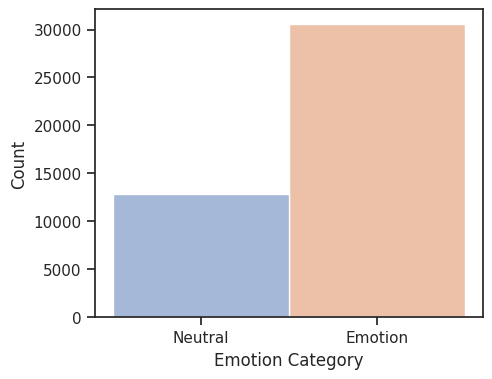

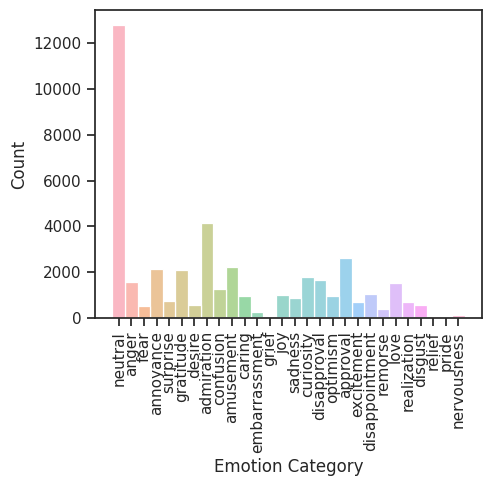

In [5]:
# Mostrar histograma
plt.figure(figsize=(5, 4))
sns.set_theme(style="ticks")
binary_labels = data_train['label_binary'].map({0: 'Neutral', 1: 'Emotion'}) # 0 -> 'Neutral', 1 -> 'Emotion'
sns.histplot(x=binary_labels, hue=binary_labels, legend=False)
plt.xlabel('Emotion Category')
plt.ylabel('Count')
plt.show()

# Mostrar histograma
plt.figure(figsize=(5, 4))
sns.set_theme(style="ticks")
sns.histplot(data=data_train, x='label_emotion', hue='label_emotion', legend=False)
plt.xlabel('Emotion Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

# Utilidades

In [6]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Loss
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

In [7]:
def classification_metrics_binary(y_true, y_prob, threshold=0.5, print_metrics=False):
    y_pred = (np.array(y_prob) >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_prob)

    if print_metrics:
        print("\nConfusion matrix:")
        print(confusion_matrix(y_true, y_pred))
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"Macro F1-score: {macro_f1:.4f}")
        print(f"AUC: {auc:.4f}")

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "macro_f1": macro_f1,
        "auc": auc
    }

# Particiones de datos

In [8]:
X_train = data_train['text']
y_train = data_train['label_binary']

X_val = data_val['text']
y_val = data_val['label_binary']

# Modelo base

In [9]:
results = []

Epoch 1/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5601 - loss: 69.1315 - val_accuracy: 0.6161 - val_loss: 17.1183
Epoch 2/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5929 - loss: 18.0435 - val_accuracy: 0.6041 - val_loss: 10.6316
Epoch 3/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6013 - loss: 11.5109 - val_accuracy: 0.5745 - val_loss: 7.1300
Epoch 4/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6041 - loss: 7.4275 - val_accuracy: 0.5863 - val_loss: 4.1268
Epoch 5/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6064 - loss: 4.6903 - val_accuracy: 0.5968 - val_loss: 2.5702
Epoch 6/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6233 - loss: 2.8977 - val_accuracy: 0.6406 - val_loss: 2.1119
Epoch 7/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6269 - loss: 1.9224 - val_accuracy: 0.5953 - val_loss: 1.0306
Epoch 8/10
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6393 - loss: 1.22

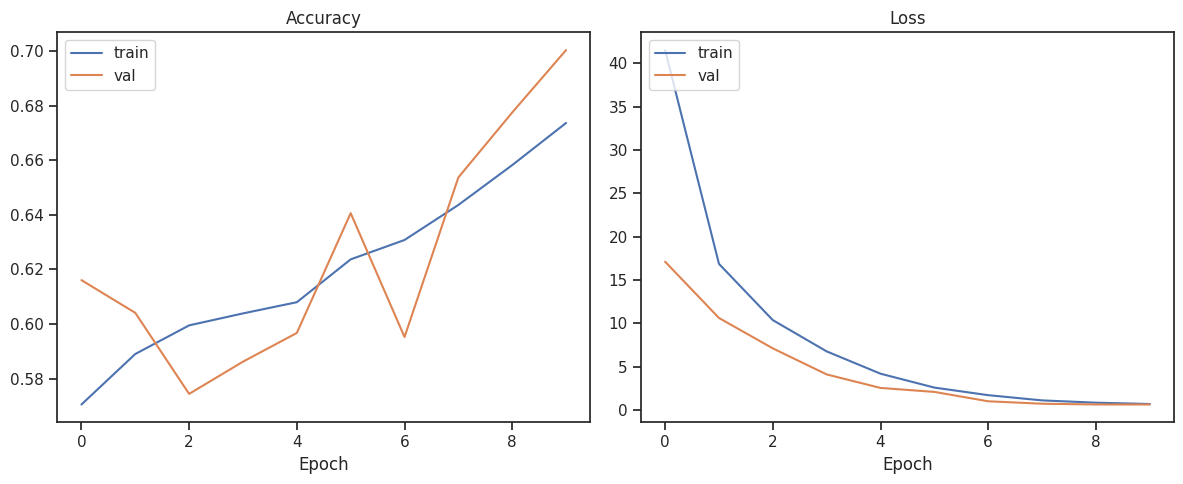

In [10]:
# Modelo base
vectorizer = TextVectorization(
    max_tokens=20000,
    output_sequence_length=100)
vectorizer.adapt(X_train)

base_model = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

base_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamiento
history = base_model.fit(
    tf.convert_to_tensor(X_train),
    y_train,
    epochs=10,
    validation_data=(tf.convert_to_tensor(X_val), y_val)
)

plot_training_history(history)

In [11]:
# Métricas de validación
y_probs = base_model.predict(tf.convert_to_tensor(X_val))
metrics_base = classification_metrics_binary(y_val, y_probs)

# Agrega una fila con los resultados al DataFrame
results.append({
    "Modelo": "Modelo base",
    "Accuracy": metrics_base["accuracy"],
    "Precision": metrics_base["precision"],
    "Recall": metrics_base["recall"],
    "Macro F1": metrics_base["macro_f1"],
    "AUC": metrics_base["auc"]
})

# Visualiza la tabla de métricas
pd.DataFrame(results)

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Modelo,Accuracy,Precision,Recall,Macro F1,AUC
0,Modelo base,0.700332,0.706047,0.986698,0.421794,0.515726
